In [10]:
# Experiment 02 — Single-image DenseNet121 Loss Comparison with Multi-seed Robustness and Confidence Analysis

This notebook keeps the original single-image DenseNet121 loss comparison from `2.loss.ipynb` and adds:

- multi-seed robustness testing for the selected best loss function
- prediction-level confidence outputs
- confidence summary, high-confidence error table, and reliability diagram
- expanded saved metrics and summary outputs


SyntaxError: invalid decimal literal (1745399917.py, line 3)

## 1. Imports & Environment Setup

In [11]:
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score
)

# Additional imports for saving, visualization, and Grad-CAM
import json
import math
from PIL import Image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch version: 2.10.0+cu128
CUDA available: True


## 2. Configuration Section

This section makes the experiment reproducible and easy to report. Only the loss function changes across the comparison runs.

In [12]:
CONFIG = {
   "EXPERIMENT_NAME": "exp02_single_image_densenet121_loss_multiseed_confidence",
   "IMG_SIZE": 224,
   "BATCH_SIZE": 16,
   "EPOCHS": 30,
   "LR": 1e-4,
   "SEED": 42,
   "SEEDS": [42, 123, 2024, 3407, 777],
   "RUN_MULTI_SEED": True,
   "DETERMINISTIC": True,
   "RUN_CONFIDENCE_ANALYSIS": True,
   "CONFIDENCE_BINS": 10,
   "MODEL_NAME": "DenseNet121",
   "LOSS": "LossComparison: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLoss",
}

CONFIG.update({
    "NUM_CLASSES": 5,
    "PATIENCE": 7,
    "WEIGHT_DECAY": 0.0,
    "USE_PRETRAINED": True,
    "SAVE_DIR": "/kaggle/working/exp02_single_image_densenet121_loss_multiseed_confidence",
    "NUM_WORKERS": 2,
})

print(json.dumps(CONFIG, indent=4))


{
    "EXPERIMENT_NAME": "exp02_single_image_densenet121_loss_multiseed_confidence",
    "IMG_SIZE": 224,
    "BATCH_SIZE": 16,
    "EPOCHS": 30,
    "LR": 0.0001,
    "SEED": 42,
    "SEEDS": [
        42,
        123,
        2024,
        3407,
        777
    ],
    "RUN_MULTI_SEED": true,
    "DETERMINISTIC": true,
    "RUN_CONFIDENCE_ANALYSIS": true,
    "CONFIDENCE_BINS": 10,
    "MODEL_NAME": "DenseNet121",
    "LOSS": "LossComparison: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLoss",
    "NUM_CLASSES": 5,
    "PATIENCE": 7,
    "WEIGHT_DECAY": 0.0,
    "USE_PRETRAINED": true,
    "SAVE_DIR": "/kaggle/working/exp02_single_image_densenet121_loss_multiseed_confidence",
    "NUM_WORKERS": 2
}


## 3. Dataset Paths

The dataset root should directly contain `train`, `val`, and `test` folders.

In [13]:
# Change this path to your own dataset folder.
# The folder should contain train/, val/, and test/.
DATA_ROOT = Path("/kaggle/input/datasets/szhang9/split-data")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

SAVE_DIR = Path(CONFIG["SAVE_DIR"])
RESULTS_DIR = SAVE_DIR / "results"
MODELS_DIR = SAVE_DIR / "models"
FIGURES_DIR = SAVE_DIR / "figures"

for p in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Output directory:", SAVE_DIR)


DATA_ROOT: /kaggle/input/datasets/szhang9/split-data
TRAIN_DIR: /kaggle/input/datasets/szhang9/split-data/train
VAL_DIR: /kaggle/input/datasets/szhang9/split-data/val
TEST_DIR: /kaggle/input/datasets/szhang9/split-data/test
Output directory: /kaggle/working/exp02_single_image_densenet121_loss_multiseed_confidence


## 4. Seed Fixing

In [14]:
def set_seed(seed=42, deterministic=True):
   """Fix random seeds for Python, NumPy, PyTorch, CUDA, and DataLoader reproducibility."""
   random.seed(seed)
   np.random.seed(seed)
   torch.manual_seed(seed)
   torch.cuda.manual_seed(seed)
   torch.cuda.manual_seed_all(seed)
   os.environ["PYTHONHASHSEED"] = str(seed)

   if deterministic:
       torch.backends.cudnn.benchmark = False
       torch.backends.cudnn.deterministic = True
       torch.use_deterministic_algorithms(True, warn_only=True)
   else:
       torch.backends.cudnn.benchmark = True
       torch.backends.cudnn.deterministic = False

set_seed(CONFIG["SEED"], deterministic=CONFIG["DETERMINISTIC"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: Tesla T4


## 5. Data Preprocessing

For this clean loss comparison, no random augmentation is used.

The preprocessing is deterministic:
- Resize
- ToTensor
- Normalize

CLAHE is shown only as a visualization preview and is not used in training.

In [15]:
IMG_SIZE = CONFIG["IMG_SIZE"]

train_transform = transforms.Compose([
   transforms.Resize((IMG_SIZE, IMG_SIZE)),
   transforms.ToTensor(),
   transforms.Normalize(
       mean=[0.485, 0.456, 0.406],
       std=[0.229, 0.224, 0.225]
   ),
])

val_transform = transforms.Compose([
   transforms.Resize((IMG_SIZE, IMG_SIZE)),
   transforms.ToTensor(),
   transforms.Normalize(
       mean=[0.485, 0.456, 0.406],
       std=[0.229, 0.224, 0.225]
   ),
])

test_transform = val_transform

print("Train transform:", train_transform)
print("Validation/Test transform:", val_transform)


Train transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Validation/Test transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 6. Dataset & Dataloader

Train dataset size: 1024
Validation dataset size: 146
Test dataset size: 294
Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Class names: ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


,split,class_idx,class_name,count
0,train,0,0Normal,316
1,train,1,1Doubtful,308
2,train,2,2Mild,134
3,train,3,3Moderate,122
4,train,4,4Severe,144
5,val,0,0Normal,45
6,val,1,1Doubtful,44
7,val,2,2Mild,19
8,val,3,3Moderate,18
9,val,4,4Severe,20


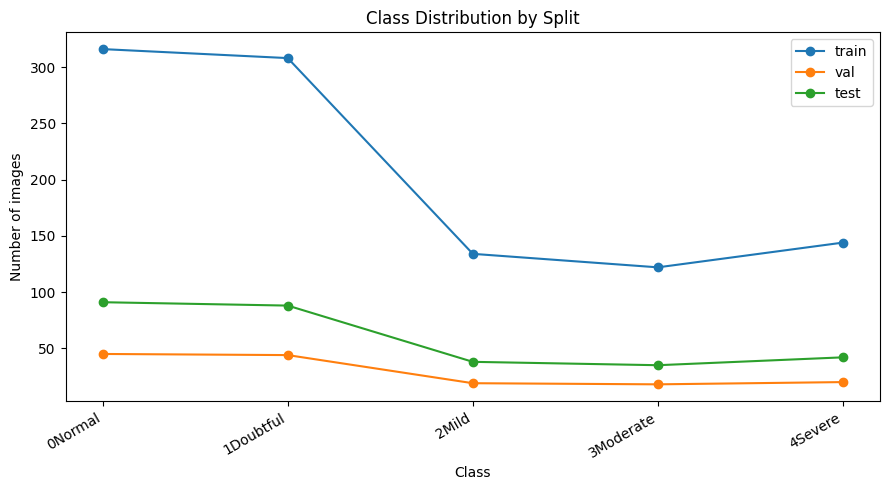

In [16]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)


def seed_worker(worker_id):
    """Make DataLoader workers reproducible."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def create_loaders(batch_size, seed=42):
    """Create train/val/test loaders with seed-controlled training shuffle."""
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=g,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
    )

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = create_loaders(CONFIG["BATCH_SIZE"], seed=CONFIG["SEED"])

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))
print("Class mapping:", train_dataset.class_to_idx)

class_names = train_dataset.classes
idx_to_class = {i: c for i, c in enumerate(class_names)}
print("Class names:", class_names)

def dataset_distribution(dataset, split_name):
    targets = np.array(dataset.targets)
    rows = []
    for class_idx, class_name in enumerate(dataset.classes):
        rows.append({
            "split": split_name,
            "class_idx": class_idx,
            "class_name": class_name,
            "count": int((targets == class_idx).sum())
        })
    return pd.DataFrame(rows)

dist_df = pd.concat([
    dataset_distribution(train_dataset, "train"),
    dataset_distribution(val_dataset, "val"),
    dataset_distribution(test_dataset, "test"),
], ignore_index=True)

display(dist_df)

plt.figure(figsize=(9, 5))
for split in ["train", "val", "test"]:
    temp = dist_df[dist_df["split"] == split]
    plt.plot(temp["class_name"], temp["count"], marker="o", label=split)
plt.title("Class Distribution by Split")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


## 7. Visualization

This section shows original image, transformed image, CLAHE preview, and a 4-crop example for explanation only. The 4-crop example is not used in this loss comparison training.

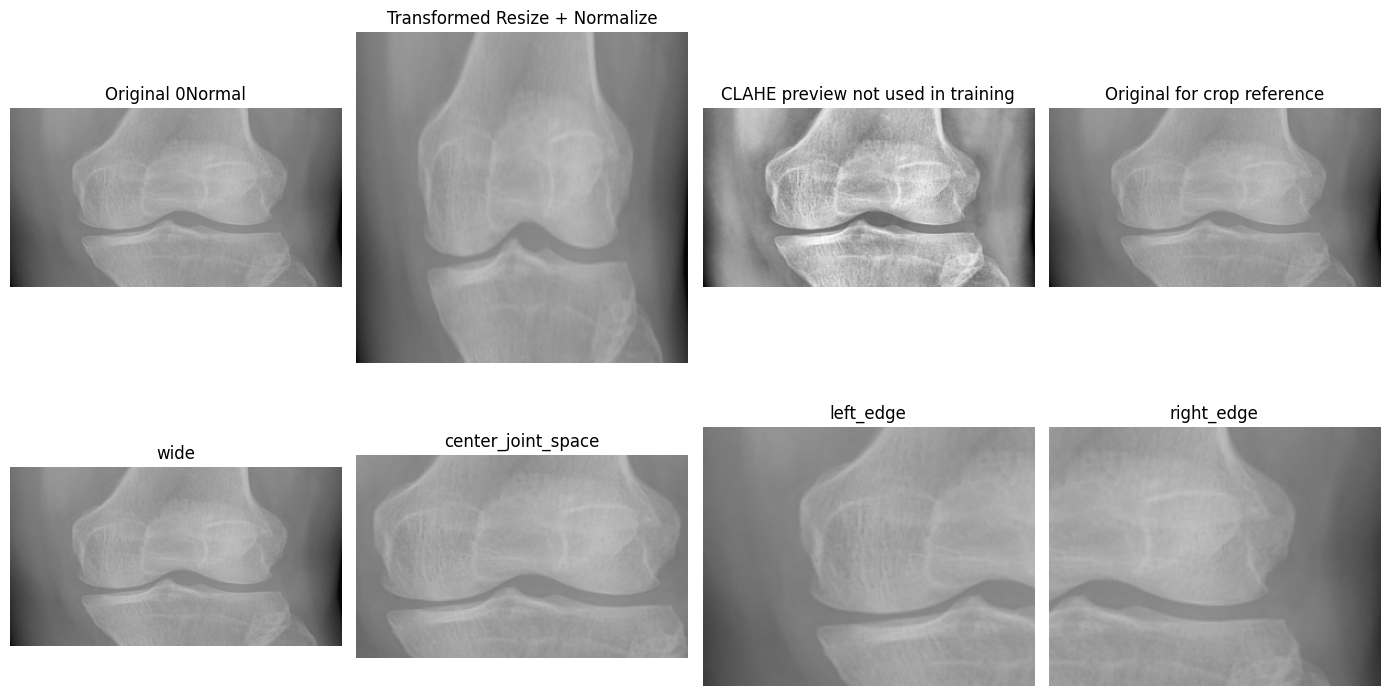

In [17]:
def denormalize_tensor(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    img = img * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def apply_clahe_preview(pil_img):
    gray = np.array(pil_img.convert("L"))
    try:
        import cv2
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
    except Exception:
        from PIL import ImageOps
        enhanced = np.array(ImageOps.equalize(Image.fromarray(gray)))
    return enhanced


def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = max(1, int(width * width_ratio))
    crop_h = max(1, int(height * height_ratio))
    cx = int(width * center_x_ratio)
    cy = int(height * center_y_ratio)
    left = max(0, min(cx - crop_w // 2, width - crop_w))
    top = max(0, min(cy - crop_h // 2, height - crop_h))
    return (left, top, left + crop_w, top + crop_h)


def show_visualization_example(dataset, sample_idx=0):
    img_path, label = dataset.samples[sample_idx]
    original = Image.open(img_path).convert("RGB")
    transformed_tensor, _ = dataset[sample_idx]
    transformed_img = denormalize_tensor(transformed_tensor)
    clahe_img = apply_clahe_preview(original)

    w, h = original.size
    crop_boxes = {
        "wide": (0, 0, w, h),
        "center_joint_space": make_crop_box(w, h, 0.50, 0.50, 0.70, 0.80),
        "left_edge": make_crop_box(w, h, 0.30, 0.50, 0.55, 0.80),
        "right_edge": make_crop_box(w, h, 0.70, 0.50, 0.55, 0.80),
    }

    plt.figure(figsize=(14, 8))
    plt.subplot(2, 4, 1)
    plt.imshow(original, cmap="gray")
    plt.title(f"Original {idx_to_class[label]}")
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.imshow(transformed_img)
    plt.title("Transformed Resize + Normalize")
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.imshow(clahe_img, cmap="gray")
    plt.title("CLAHE preview not used in training")
    plt.axis("off")

    plt.subplot(2, 4, 4)
    plt.imshow(original, cmap="gray")
    plt.title("Original for crop reference")
    plt.axis("off")

    for plot_idx, (crop_name, box) in enumerate(crop_boxes.items(), start=5):
        crop = original.crop(box)
        plt.subplot(2, 4, plot_idx)
        plt.imshow(crop, cmap="gray")
        plt.title(crop_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_visualization_example(train_dataset, sample_idx=0)


## 8. Model Definition

This experiment uses a single-image DenseNet121 model. The model takes one full X-ray image and predicts one of five OA severity grades.

In [18]:
def build_densenet121(num_classes=5, pretrained=True):
    try:
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
    except Exception:
        model = models.densenet121(pretrained=pretrained)

    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

_demo_model = build_densenet121(num_classes=CONFIG["NUM_CLASSES"], pretrained=CONFIG["USE_PRETRAINED"])
print(_demo_model.classifier)
del _demo_model


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 241MB/s]

Linear(in_features=1024, out_features=5, bias=True)


## 9. Loss Function

This section defines and prints the matrices for the ordinal-aware losses.

Compared losses:
1. **OrdinalCrossEntropyLoss**: CE + expected-grade MSE penalty.
2. **ChenOrdinalLoss**: Chen-style ordinal penalty matrix only.
3. **HybridChenOrdinalLoss**: CE + Chen-style ordinal penalty.

Ordinal-aware loss is used to reduce severe grading errors, because predicting a grade that is far away from the true grade should be penalized more than an adjacent mistake.

In [19]:
class OrdinalCrossEntropyLoss(nn.Module):
    def __init__(self, num_classes=5, alpha=0.2):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.ce_loss = nn.CrossEntropyLoss()
        class_values = torch.arange(num_classes, dtype=torch.float32)
        self.register_buffer("class_values", class_values)

    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        probabilities = torch.softmax(logits, dim=1)
        expected_grade = torch.sum(probabilities * self.class_values.to(logits.device), dim=1)
        ordinal_mse = torch.mean((expected_grade - targets.float()) ** 2)
        return ce + self.alpha * ordinal_mse

    def get_distance_matrix(self):
        idx = torch.arange(self.num_classes, dtype=torch.float32)
        return (idx[:, None] - idx[None, :]).abs() ** 2


class ChenOrdinalLoss(nn.Module):
    def __init__(self, num_classes=5, penalty_distance=2, square_loss=True, normalize=False):
        super().__init__()
        self.num_classes = num_classes
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize
        penalty_matrix = self._create_penalty_matrix(num_classes, penalty_distance, normalize)
        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)
        distance_matrix = torch.abs(class_indices.unsqueeze(0) - class_indices.unsqueeze(1))
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0
        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value
        return penalty_matrix

    def forward(self, logits, targets):
        probabilities = torch.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix.to(logits.device)[targets.long()]
        loss_per_sample = torch.sum(probabilities * target_penalties, dim=1)
        if self.square_loss:
            loss_per_sample = loss_per_sample ** 2
        return torch.mean(loss_per_sample)


class HybridChenOrdinalLoss(nn.Module):
    def __init__(self, num_classes=5, alpha=0.1, penalty_distance=2, square_loss=False, normalize=True):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize
        self.ce_loss = nn.CrossEntropyLoss()
        penalty_matrix = self._create_penalty_matrix(num_classes, penalty_distance, normalize)
        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)
        distance_matrix = torch.abs(class_indices.unsqueeze(0) - class_indices.unsqueeze(1))
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0
        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value
        return penalty_matrix

    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        probabilities = torch.softmax(logits, dim=1)
        target_penalties = self.penalty_matrix.to(logits.device)[targets.long()]
        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)
        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2
        ordinal_penalty = torch.mean(penalty_per_sample)
        return ce + self.alpha * ordinal_penalty


def build_criterion(loss_name):
    if loss_name == "OrdinalCrossEntropyLoss":
        return OrdinalCrossEntropyLoss(num_classes=CONFIG["NUM_CLASSES"], alpha=0.2)
    if loss_name == "ChenOrdinalLoss":
        return ChenOrdinalLoss(num_classes=CONFIG["NUM_CLASSES"], penalty_distance=2, square_loss=True, normalize=False)
    if loss_name == "HybridChenOrdinalLoss":
        return HybridChenOrdinalLoss(num_classes=CONFIG["NUM_CLASSES"], alpha=0.1, penalty_distance=2, square_loss=False, normalize=True)
    raise ValueError(f"Unknown loss: {loss_name}")

LOSS_EXPERIMENTS = [
    "OrdinalCrossEntropyLoss",
    "ChenOrdinalLoss",
    "HybridChenOrdinalLoss",
]

loss_matrix_records = {}
for loss_name in LOSS_EXPERIMENTS:
    criterion = build_criterion(loss_name)
    print("=" * 80)
    print("Loss:", loss_name)
    print(criterion)

    if isinstance(criterion, OrdinalCrossEntropyLoss):
        matrix = criterion.get_distance_matrix().cpu().numpy()
        print("Class values:", criterion.class_values.cpu().numpy())
        print("Implied squared ordinal distance matrix:")
        print(matrix)
    else:
        matrix = criterion.penalty_matrix.cpu().numpy()
        print("Penalty matrix:")
        print(matrix)
    loss_matrix_records[loss_name] = matrix.tolist()


Loss: OrdinalCrossEntropyLoss
OrdinalCrossEntropyLoss(
  (ce_loss): CrossEntropyLoss()
)
Class values: [0. 1. 2. 3. 4.]
Implied squared ordinal distance matrix:
[[ 0.  1.  4.  9. 16.]
 [ 1.  0.  1.  4.  9.]
 [ 4.  1.  0.  1.  4.]
 [ 9.  4.  1.  0.  1.]
 [16.  9.  4.  1.  0.]]
Loss: ChenOrdinalLoss
ChenOrdinalLoss()
Penalty matrix:
[[0. 3. 5. 7. 9.]
 [3. 0. 3. 5. 7.]
 [5. 3. 0. 3. 5.]
 [7. 5. 3. 0. 3.]
 [9. 7. 5. 3. 0.]]
Loss: HybridChenOrdinalLoss
HybridChenOrdinalLoss(
  (ce_loss): CrossEntropyLoss()
)
Penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]


## 10. Optimizer & Scheduler

In [20]:
def build_optimizer_and_scheduler(model):
    optimizer = torch.optim.AdamW(
       model.parameters(),
       lr=CONFIG["LR"],
       weight_decay=CONFIG["WEIGHT_DECAY"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["EPOCHS"]
    )
    return optimizer, scheduler

print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")


Optimizer: AdamW
Scheduler: CosineAnnealingLR


## 11. Training Loop

In [21]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    diff = np.abs(y_true - y_pred)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "mae": float(np.mean(diff)),
        "total_errors": int(np.sum(diff > 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
    }


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(running_loss / len(loader.dataset))
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    y_true, y_pred = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = float(running_loss / len(loader.dataset))
    return metrics, np.array(y_true), np.array(y_pred)


def train_single_loss_experiment(loss_name, seed=None, result_tag=None):
    seed = CONFIG["SEED"] if seed is None else seed
    save_tag = result_tag if result_tag is not None else loss_name

    print("=" * 90)
    print("Starting loss experiment:", loss_name)
    print("Seed:", seed)
    print("Save tag:", save_tag)
    print("=" * 90)

    set_seed(seed, deterministic=CONFIG["DETERMINISTIC"])
    local_train_loader, local_val_loader, _ = create_loaders(CONFIG["BATCH_SIZE"], seed=seed)

    model = build_densenet121(CONFIG["NUM_CLASSES"], CONFIG["USE_PRETRAINED"]).to(device)
    criterion = build_criterion(loss_name).to(device)
    optimizer, scheduler = build_optimizer_and_scheduler(model)
    model_path = MODELS_DIR / f"{save_tag}_best.pth"
    history = []
    best_val_qwk = -999
    best_epoch = 0
    best_val_metrics = None
    patience_counter = 0

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        train_metrics = train_one_epoch(model, local_train_loader, criterion, optimizer)
        val_metrics, _, _ = evaluate(model, local_val_loader, criterion)
        scheduler.step()
        row = {
            "epoch": epoch,
            "loss_name": loss_name,
            "save_tag": save_tag,
            "seed": seed,
            "train_loss": train_metrics["loss"],
            "val_loss": val_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_accuracy": val_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "train_qwk": train_metrics["qwk"],
            "val_qwk": val_metrics["qwk"],
            "train_mae": train_metrics["mae"],
            "val_mae": val_metrics["mae"],
            "val_adjacent_errors": val_metrics["adjacent_errors"],
            "val_distant_errors": val_metrics["distant_errors"],
        }
        history.append(row)
        print(
            f"[{loss_name} | seed={seed}] Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
            f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} val_qwk={val_metrics['qwk']:.4f} "
            f"val_mae={val_metrics['mae']:.4f} val_macro_f1={val_metrics['macro_f1']:.4f}"
        )
        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            best_val_metrics = dict(val_metrics)
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print(f"  Saved best model for {loss_name} at epoch {epoch} with val_qwk={best_val_qwk:.4f}")
        else:
            patience_counter += 1
        if patience_counter >= CONFIG["PATIENCE"]:
            print(f"  Early stopping at epoch {epoch}")
            break

    history_df = pd.DataFrame(history)
    history_path = RESULTS_DIR / f"{save_tag}_history.csv"
    history_df.to_csv(history_path, index=False)
    del model
    torch.cuda.empty_cache()
    return {
        "loss_name": loss_name,
        "save_tag": save_tag,
        "seed": int(seed),
        "model_path": str(model_path),
        "history_path": str(history_path),
        "best_epoch": int(best_epoch),
        "best_val_qwk": float(best_val_qwk),
        "best_val_accuracy": float(best_val_metrics["accuracy"]) if best_val_metrics else np.nan,
        "best_val_macro_f1": float(best_val_metrics["macro_f1"]) if best_val_metrics else np.nan,
        "best_val_weighted_f1": float(best_val_metrics["weighted_f1"]) if best_val_metrics else np.nan,
        "best_val_mae": float(best_val_metrics["mae"]) if best_val_metrics else np.nan,
        "best_val_total_errors": int(best_val_metrics["total_errors"]) if best_val_metrics else np.nan,
        "best_val_adjacent_errors": int(best_val_metrics["adjacent_errors"]) if best_val_metrics else np.nan,
        "best_val_distant_errors": int(best_val_metrics["distant_errors"]) if best_val_metrics else np.nan,
        "history_df": history_df,
    }

print("Training utilities are ready.")


Training utilities are ready.


In [22]:
all_experiment_records = []
for loss_name in LOSS_EXPERIMENTS:
    record = train_single_loss_experiment(loss_name)
    all_experiment_records.append(record)
print("All loss experiments completed.")


Starting loss experiment: OrdinalCrossEntropyLoss
Seed: 42
Save tag: OrdinalCrossEntropyLoss
[OrdinalCrossEntropyLoss | seed=42] Epoch 01/30 | train_loss=1.2551 val_loss=0.8574 | val_acc=0.7260 val_qwk=0.8232 val_mae=0.4110 val_macro_f1=0.6587
  Saved best model for OrdinalCrossEntropyLoss at epoch 1 with val_qwk=0.8232
[OrdinalCrossEntropyLoss | seed=42] Epoch 02/30 | train_loss=0.6397 val_loss=0.8816 | val_acc=0.6781 val_qwk=0.8158 val_mae=0.4315 val_macro_f1=0.6471
[OrdinalCrossEntropyLoss | seed=42] Epoch 03/30 | train_loss=0.4385 val_loss=0.7818 | val_acc=0.7397 val_qwk=0.8607 val_mae=0.3493 val_macro_f1=0.7166
  Saved best model for OrdinalCrossEntropyLoss at epoch 3 with val_qwk=0.8607
[OrdinalCrossEntropyLoss | seed=42] Epoch 04/30 | train_loss=0.2134 val_loss=0.6798 | val_acc=0.8356 val_qwk=0.9024 val_mae=0.2260 val_macro_f1=0.7870
  Saved best model for OrdinalCrossEntropyLoss at epoch 4 with val_qwk=0.9024
[OrdinalCrossEntropyLoss | seed=42] Epoch 05/30 | train_loss=0.1384 v

## 12. Validation Section

,loss_name,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_mae,best_val_adjacent_errors,best_val_distant_errors
0,OrdinalCrossEntropyLoss,11,0.919082,0.828767,0.795811,0.212329,21,4
1,ChenOrdinalLoss,5,0.915619,0.773973,0.731446,0.260274,29,4
2,HybridChenOrdinalLoss,14,0.888504,0.746575,0.735757,0.308219,32,5


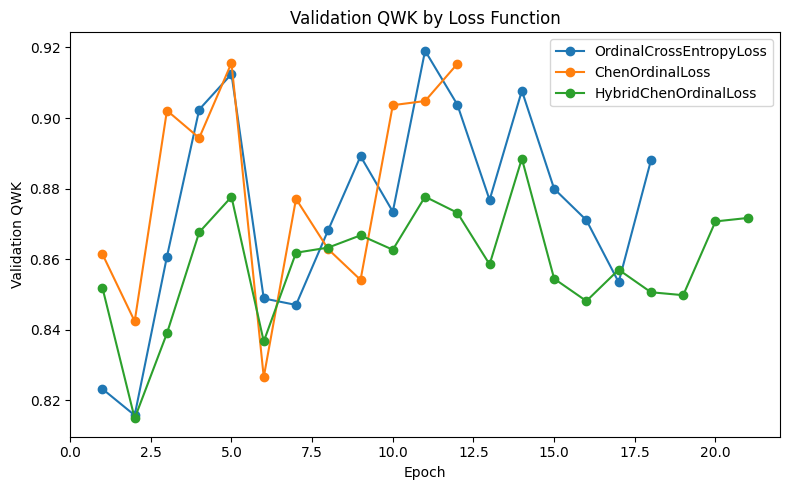

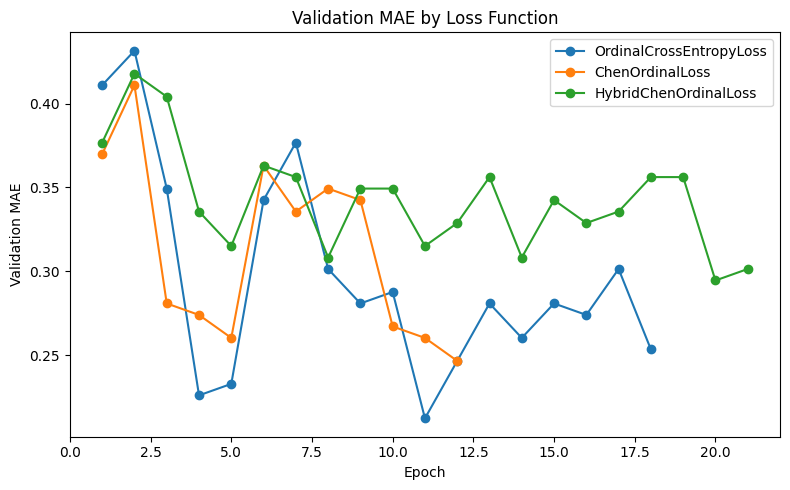

In [23]:
val_summary_rows = []
for record in all_experiment_records:
    hist = record["history_df"]
    best_row_val = hist.loc[hist["val_qwk"].idxmax()].to_dict()
    val_summary_rows.append({
        "loss_name": record["loss_name"],
        "best_epoch": record["best_epoch"],
        "best_val_qwk": record["best_val_qwk"],
        "best_val_accuracy": best_row_val["val_accuracy"],
        "best_val_macro_f1": best_row_val["val_macro_f1"],
        "best_val_mae": best_row_val["val_mae"],
        "best_val_adjacent_errors": best_row_val["val_adjacent_errors"],
        "best_val_distant_errors": best_row_val["val_distant_errors"],
    })
val_summary_df = pd.DataFrame(val_summary_rows).sort_values("best_val_qwk", ascending=False)
display(val_summary_df)

plt.figure(figsize=(8, 5))
for record in all_experiment_records:
    hist = record["history_df"]
    plt.plot(hist["epoch"], hist["val_qwk"], marker="o", label=record["loss_name"])
plt.title("Validation QWK by Loss Function")
plt.xlabel("Epoch")
plt.ylabel("Validation QWK")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for record in all_experiment_records:
    hist = record["history_df"]
    plt.plot(hist["epoch"], hist["val_mae"], marker="o", label=record["loss_name"])
plt.title("Validation MAE by Loss Function")
plt.xlabel("Epoch")
plt.ylabel("Validation MAE")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Test Evaluation

In [24]:
def load_best_model_for_loss(loss_name, model_path):
    model = build_densenet121(CONFIG["NUM_CLASSES"], CONFIG["USE_PRETRAINED"]).to(device)
    try:
        state_dict = torch.load(model_path, map_location=device, weights_only=True)
    except TypeError:
        state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

test_results = []
test_predictions = {}
for record in all_experiment_records:
    loss_name = record["loss_name"]
    model = load_best_model_for_loss(loss_name, record["model_path"])
    criterion = build_criterion(loss_name).to(device)
    test_metrics, test_true, test_pred = evaluate(model, test_loader, criterion)
    test_predictions[loss_name] = {"y_true": test_true, "y_pred": test_pred}
    row = {
        "loss_name": loss_name,
        "save_tag": record["save_tag"],
        "seed": record["seed"],
        "best_epoch": record["best_epoch"],
        "best_val_qwk": record["best_val_qwk"],
        **test_metrics,
    }
    test_results.append(row)
    print("=" * 80)
    print("Test results for:", loss_name)
    for k, v in test_metrics.items():
        print(f"{k}: {v}")
    del model
    torch.cuda.empty_cache()

test_results_df = pd.DataFrame(test_results).sort_values("qwk", ascending=False)
display(test_results_df)
test_results_df.to_csv(RESULTS_DIR / "loss_comparison_test_results.csv", index=False)


Test results for: OrdinalCrossEntropyLoss
accuracy: 0.7891156462585034
macro_f1: 0.7725219949484655
weighted_f1: 0.785284872207141
qwk: 0.8418575071175117
mae: 0.3163265306122449
total_errors: 62
adjacent_errors: 43
distant_errors: 19
loss: 0.7692504543430951
Test results for: ChenOrdinalLoss
accuracy: 0.7721088435374149
macro_f1: 0.751358740228864
weighted_f1: 0.7669884123551466
qwk: 0.8671992631038209
mae: 0.30952380952380953
total_errors: 67
adjacent_errors: 50
distant_errors: 17
loss: 3.1460475175559117
Test results for: HybridChenOrdinalLoss
accuracy: 0.7517006802721088
macro_f1: 0.7386323419279487
weighted_f1: 0.750697938700203
qwk: 0.8445225247835362
mae: 0.3435374149659864
total_errors: 73
adjacent_errors: 54
distant_errors: 19
loss: 0.8248898486296335


,loss_name,save_tag,seed,best_epoch,best_val_qwk,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,loss
1,ChenOrdinalLoss,ChenOrdinalLoss,42,5,0.915619,0.772109,0.751359,0.766988,0.867199,0.309524,67,50,17,3.146048
2,HybridChenOrdinalLoss,HybridChenOrdinalLoss,42,14,0.888504,0.751701,0.738632,0.750698,0.844523,0.343537,73,54,19,0.824890
0,OrdinalCrossEntropyLoss,OrdinalCrossEntropyLoss,42,11,0.919082,0.789116,0.772522,0.785285,0.841858,0.316327,62,43,19,0.769250


## 13.1 Multi-seed Robustness Experiment


In [25]:
# ============================================================
# Multi-seed robustness experiment for the selected best loss
# ============================================================

seed_results_df = pd.DataFrame()
multi_seed_summary_df = pd.DataFrame()
seed_test_predictions = {}

if CONFIG.get("RUN_MULTI_SEED", True):
    selected_loss_name = str(test_results_df.iloc[0]["loss_name"])
    print("Selected loss for multi-seed experiment:", selected_loss_name)
    print("Seeds:", CONFIG["SEEDS"])

    seed_results = []

    for seed in CONFIG["SEEDS"]:
        print("\n" + "#" * 90)
        print(f"Running selected loss {selected_loss_name} with seed = {seed}")
        print("#" * 90)

        if seed == CONFIG["SEED"]:
            print(f"Reusing initial loss-comparison result for seed={seed}.")
            base_record = next(r for r in all_experiment_records if r["loss_name"] == selected_loss_name)
            result = {
                "loss_name": selected_loss_name,
                "save_tag": base_record["save_tag"],
                "seed": seed,
                "best_epoch": base_record["best_epoch"],
                "best_val_qwk": base_record["best_val_qwk"],
                "best_val_accuracy": base_record["best_val_accuracy"],
                "best_val_macro_f1": base_record["best_val_macro_f1"],
                "best_val_weighted_f1": base_record["best_val_weighted_f1"],
                "best_val_mae": base_record["best_val_mae"],
                "best_val_total_errors": base_record["best_val_total_errors"],
                "best_val_adjacent_errors": base_record["best_val_adjacent_errors"],
                "best_val_distant_errors": base_record["best_val_distant_errors"],
                "model_path": base_record["model_path"],
            }
            seed_metrics = test_results_df[test_results_df["loss_name"] == selected_loss_name].iloc[0].to_dict()
            for src_key, dst_key in [
                ("accuracy", "test_accuracy"),
                ("macro_f1", "test_macro_f1"),
                ("weighted_f1", "test_weighted_f1"),
                ("qwk", "test_qwk"),
                ("mae", "test_mae"),
                ("total_errors", "test_total_errors"),
                ("adjacent_errors", "test_adjacent_errors"),
                ("distant_errors", "test_distant_errors"),
            ]:
                result[dst_key] = seed_metrics[src_key]
            test_true = test_predictions[selected_loss_name]["y_true"]
            test_pred = test_predictions[selected_loss_name]["y_pred"]
        else:
            run_record = train_single_loss_experiment(
                selected_loss_name,
                seed=seed,
                result_tag=f"{selected_loss_name}_seed{seed}",
            )
            model = load_best_model_for_loss(selected_loss_name, run_record["model_path"])
            criterion = build_criterion(selected_loss_name).to(device)
            _, _, local_test_loader = create_loaders(CONFIG["BATCH_SIZE"], seed=seed)
            test_metrics, test_true, test_pred = evaluate(model, local_test_loader, criterion)
            result = {
                "loss_name": selected_loss_name,
                "save_tag": run_record["save_tag"],
                "seed": seed,
                "best_epoch": run_record["best_epoch"],
                "best_val_qwk": run_record["best_val_qwk"],
                "best_val_accuracy": run_record["best_val_accuracy"],
                "best_val_macro_f1": run_record["best_val_macro_f1"],
                "best_val_weighted_f1": run_record["best_val_weighted_f1"],
                "best_val_mae": run_record["best_val_mae"],
                "best_val_total_errors": run_record["best_val_total_errors"],
                "best_val_adjacent_errors": run_record["best_val_adjacent_errors"],
                "best_val_distant_errors": run_record["best_val_distant_errors"],
                "model_path": run_record["model_path"],
                "test_accuracy": test_metrics["accuracy"],
                "test_macro_f1": test_metrics["macro_f1"],
                "test_weighted_f1": test_metrics["weighted_f1"],
                "test_qwk": test_metrics["qwk"],
                "test_mae": test_metrics["mae"],
                "test_total_errors": test_metrics["total_errors"],
                "test_adjacent_errors": test_metrics["adjacent_errors"],
                "test_distant_errors": test_metrics["distant_errors"],
            }
            del model
            torch.cuda.empty_cache()

        seed_results.append(result)
        seed_test_predictions[seed] = {
            "true": test_true,
            "pred": test_pred,
            "model_path": result["model_path"],
        }

    seed_results_df = pd.DataFrame(seed_results)
    seed_results_df.to_csv(RESULTS_DIR / "multi_seed_test_results.csv", index=False)

    display(seed_results_df)
else:
    selected_loss_name = str(test_results_df.iloc[0]["loss_name"])
    print("Multi-seed experiment skipped because CONFIG['RUN_MULTI_SEED'] is False.")


Selected loss for multi-seed experiment: ChenOrdinalLoss
Seeds: [42, 123, 2024, 3407, 777]

##########################################################################################
Running selected loss ChenOrdinalLoss with seed = 42
##########################################################################################
Reusing initial loss-comparison result for seed=42.

##########################################################################################
Running selected loss ChenOrdinalLoss with seed = 123
##########################################################################################
Starting loss experiment: ChenOrdinalLoss
Seed: 123
Save tag: ChenOrdinalLoss_seed123
[ChenOrdinalLoss | seed=123] Epoch 01/30 | train_loss=8.3246 val_loss=4.8866 | val_acc=0.6233 val_qwk=0.7730 val_mae=0.5137 val_macro_f1=0.5460
  Saved best model for ChenOrdinalLoss at epoch 1 with val_qwk=0.7730
[ChenOrdinalLoss | seed=123] Epoch 02/30 | train_loss=2.8515 val_loss=3.4174 | val_a

,loss_name,save_tag,seed,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_weighted_f1,best_val_mae,best_val_total_errors,...,best_val_distant_errors,model_path,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors
0,ChenOrdinalLoss,ChenOrdinalLoss,42,5,0.915619,0.773973,0.731446,0.760762,0.260274,33,...,4,/kaggle/working/exp02_single_image_densenet121...,0.772109,0.751359,0.766988,0.867199,0.309524,67,50,17
1,ChenOrdinalLoss,ChenOrdinalLoss_seed123,123,20,0.936263,0.801370,0.764764,0.788883,0.212329,29,...,1,/kaggle/working/exp02_single_image_densenet121...,0.768707,0.748496,0.764964,0.882260,0.295918,68,54,14
2,ChenOrdinalLoss,ChenOrdinalLoss_seed2024,2024,5,0.920832,0.801370,0.772153,0.795349,0.232877,29,...,4,/kaggle/working/exp02_single_image_densenet121...,0.751701,0.729902,0.746790,0.877331,0.306122,73,62,11
3,ChenOrdinalLoss,ChenOrdinalLoss_seed3407,3407,13,0.932938,0.821918,0.778816,0.807503,0.205479,26,...,3,/kaggle/working/exp02_single_image_densenet121...,0.775510,0.759008,0.771759,0.861651,0.306122,66,51,15
4,ChenOrdinalLoss,ChenOrdinalLoss_seed777,777,5,0.938414,0.808219,0.786221,0.798844,0.205479,28,...,1,/kaggle/working/exp02_single_image_densenet121...,0.768707,0.761538,0.766683,0.867291,0.309524,68,52,16


## 13.2 Multi-seed Summary: Mean ± Standard Deviation


In [26]:
# ============================================================
# Multi-seed summary: mean ± std
# ============================================================

metric_cols = [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_qwk",
    "test_mae",
    "test_total_errors",
    "test_adjacent_errors",
    "test_distant_errors",
]

summary_rows = []

if len(seed_results_df) > 0:
    for metric in metric_cols:
        values = seed_results_df[metric].astype(float)

        summary_rows.append({
            "metric": metric,
            "mean": float(values.mean()),
            "std": float(values.std(ddof=0)),
            "min": float(values.min()),
            "max": float(values.max()),
            "mean±std": f"{values.mean():.4f} ± {values.std(ddof=0):.4f}",
        })

    multi_seed_summary_df = pd.DataFrame(summary_rows)
    multi_seed_summary_df.to_csv(RESULTS_DIR / "multi_seed_summary.csv", index=False)

    display(multi_seed_summary_df)
else:
    print("No multi-seed results available.")


,metric,mean,std,min,max,mean±std
0,test_accuracy,0.767347,0.008220,0.751701,0.775510,0.7673 ± 0.0082
1,test_macro_f1,0.750060,0.011156,0.729902,0.761538,0.7501 ± 0.0112
2,test_weighted_f1,0.763437,0.008624,0.746790,0.771759,0.7634 ± 0.0086
3,test_qwk,0.871146,0.007515,0.861651,0.882260,0.8711 ± 0.0075
4,test_mae,0.305442,0.004999,0.295918,0.309524,0.3054 ± 0.0050
5,test_total_errors,68.400000,2.416609,66.000000,73.000000,68.4000 ± 2.4166
6,test_adjacent_errors,53.800000,4.308132,50.000000,62.000000,53.8000 ± 4.3081
7,test_distant_errors,14.600000,2.059126,11.000000,17.000000,14.6000 ± 2.0591


## 13.3 Selected Loss Confidence and Calibration Analysis


In [27]:
# ============================================================
# Selected loss confidence and calibration analysis
# ============================================================

def expected_calibration_error(confidences, correct, n_bins=10):
    confidences = np.array(confidences)
    correct = np.array(correct).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            bin_accuracy = np.mean(correct[in_bin])
            bin_confidence = np.mean(confidences[in_bin])
            ece += prop_in_bin * abs(bin_accuracy - bin_confidence)

    return float(ece)


def evaluate_with_confidence(model, loader, criterion=None, desc="confidence_eval"):
    model.eval()

    running_loss = 0.0
    records = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)

            if criterion is not None:
                loss = criterion(logits, labels)
                running_loss += loss.item() * labels.size(0)

            probs = F.softmax(logits, dim=1)
            confidences, preds = torch.max(probs, dim=1)
            top2 = torch.topk(probs, k=2, dim=1).values
            margins = top2[:, 0] - top2[:, 1]

            entropy = -(probs * torch.log(probs + 1e-12)).sum(dim=1)
            entropy = entropy / math.log(CONFIG["NUM_CLASSES"])

            probs_cpu = probs.detach().cpu().numpy()
            labels_cpu = labels.detach().cpu().numpy()
            preds_cpu = preds.detach().cpu().numpy()
            conf_cpu = confidences.detach().cpu().numpy()
            margin_cpu = margins.detach().cpu().numpy()
            entropy_cpu = entropy.detach().cpu().numpy()

            for i in range(labels.size(0)):
                true_label = int(labels_cpu[i])
                pred_label = int(preds_cpu[i])
                correct = true_label == pred_label

                row = {
                    "sample_index": batch_idx * loader.batch_size + i,
                    "true": true_label,
                    "pred": pred_label,
                    "true_class": class_names[true_label],
                    "pred_class": class_names[pred_label],
                    "correct": bool(correct),
                    "confidence": float(conf_cpu[i]),
                    "margin_top1_top2": float(margin_cpu[i]),
                    "entropy": float(entropy_cpu[i]),
                }

                for class_idx, class_name in enumerate(class_names):
                    row[f"prob_{class_idx}_{class_name}"] = float(probs_cpu[i, class_idx])

                records.append(row)

    conf_df = pd.DataFrame(records)
    y_true = conf_df["true"].values
    y_pred = conf_df["pred"].values

    metrics = compute_metrics(y_true, y_pred)

    if criterion is not None:
        metrics["loss"] = running_loss / len(loader.dataset)

    correct_mask = conf_df["correct"].values.astype(bool)

    def safe_mean(values):
        values = np.array(values)
        if len(values) == 0:
            return np.nan
        return float(np.mean(values))

    confidence_summary = {
        "mean_confidence": float(conf_df["confidence"].mean()),
        "median_confidence": float(conf_df["confidence"].median()),
        "mean_confidence_correct": safe_mean(conf_df.loc[correct_mask, "confidence"]),
        "mean_confidence_wrong": safe_mean(conf_df.loc[~correct_mask, "confidence"]),
        "mean_margin_top1_top2": float(conf_df["margin_top1_top2"].mean()),
        "mean_entropy": float(conf_df["entropy"].mean()),
        "high_confidence_wrong_count_0.80": int(((conf_df["confidence"] >= 0.80) & (~conf_df["correct"])).sum()),
        "high_confidence_wrong_count_0.90": int(((conf_df["confidence"] >= 0.90) & (~conf_df["correct"])).sum()),
        "ece_10_bins": expected_calibration_error(
            conf_df["confidence"].values,
            conf_df["correct"].values,
            n_bins=CONFIG.get("CONFIDENCE_BINS", 10)
        ),
    }

    return metrics, conf_df, confidence_summary


confidence_metrics = {}
confidence_summary = {}
confidence_df = pd.DataFrame()
confidence_by_class_df = pd.DataFrame()
high_confidence_wrong_df = pd.DataFrame()

if CONFIG.get("RUN_CONFIDENCE_ANALYSIS", True):
    selected_loss_name = str(test_results_df.iloc[0]["loss_name"])
    selected_record = next(r for r in all_experiment_records if r["loss_name"] == selected_loss_name)

    confidence_model = load_best_model_for_loss(selected_loss_name, selected_record["model_path"])
    confidence_criterion = build_criterion(selected_loss_name).to(device)
    _, _, confidence_test_loader = create_loaders(CONFIG["BATCH_SIZE"], seed=CONFIG["SEED"])

    confidence_metrics, confidence_df, confidence_summary = evaluate_with_confidence(
        confidence_model,
        confidence_test_loader,
        criterion=confidence_criterion,
        desc="selected loss confidence",
    )

    confidence_df.to_csv(RESULTS_DIR / "selected_loss_confidence_predictions.csv", index=False)

    confidence_summary_df = pd.DataFrame([confidence_summary])
    confidence_summary_df.to_csv(RESULTS_DIR / "selected_loss_confidence_summary.csv", index=False)

    confidence_by_class_df = (
        confidence_df
        .groupby("true_class")
        .agg(
            samples=("sample_index", "count"),
            accuracy=("correct", "mean"),
            mean_confidence=("confidence", "mean"),
            mean_margin=("margin_top1_top2", "mean"),
            mean_entropy=("entropy", "mean"),
        )
        .reset_index()
    )
    confidence_by_class_df.to_csv(RESULTS_DIR / "selected_loss_confidence_by_true_class.csv", index=False)

    high_confidence_wrong_df = confidence_df[
        (confidence_df["confidence"] >= 0.80) & (~confidence_df["correct"])
    ].sort_values("confidence", ascending=False)
    high_confidence_wrong_df.to_csv(RESULTS_DIR / "selected_loss_high_confidence_wrong.csv", index=False)

    print("Confidence metrics:")
    print(json.dumps(confidence_metrics, indent=2))

    print("\nConfidence summary:")
    print(json.dumps(confidence_summary, indent=2))

    print("\nConfidence by true class:")
    display(confidence_by_class_df)

    print("\nFirst few prediction-level confidence records:")
    display(confidence_df.head())

    print("\nHigh-confidence wrong predictions, confidence >= 0.80:")
    display(high_confidence_wrong_df.head(20))

    del confidence_model
    torch.cuda.empty_cache()
else:
    print("Confidence analysis skipped because CONFIG['RUN_CONFIDENCE_ANALYSIS'] is False.")


Confidence metrics:
{
  "accuracy": 0.7721088435374149,
  "macro_f1": 0.751358740228864,
  "weighted_f1": 0.7669884123551466,
  "qwk": 0.8671992631038209,
  "mae": 0.30952380952380953,
  "total_errors": 67,
  "adjacent_errors": 50,
  "distant_errors": 17,
  "loss": 3.1460475175559117
}

Confidence summary:
{
  "mean_confidence": 0.8239725281794866,
  "median_confidence": 0.874908983707428,
  "mean_confidence_correct": 0.8477722571809911,
  "mean_confidence_wrong": 0.7433376254430458,
  "mean_margin_top1_top2": 0.6912022366815683,
  "mean_entropy": 0.31215356498145735,
  "high_confidence_wrong_count_0.80": 27,
  "high_confidence_wrong_count_0.90": 15,
  "ece_10_bins": 0.06926930852893257
}

Confidence by true class:


,true_class,samples,accuracy,mean_confidence,mean_margin,mean_entropy
0,0Normal,91,0.879121,0.891249,0.797545,0.205507
1,1Doubtful,88,0.784091,0.813955,0.661828,0.318471
2,2Mild,38,0.421053,0.748375,0.578152,0.429711
3,3Moderate,35,0.800000,0.782561,0.628580,0.371783
4,4Severe,42,0.809524,0.802104,0.676808,0.373932



First few prediction-level confidence records:


,sample_index,true,pred,true_class,pred_class,correct,confidence,margin_top1_top2,entropy,prob_0_0Normal,prob_1_1Doubtful,prob_2_2Mild,prob_3_3Moderate,prob_4_4Severe
0,0,0,0,0Normal,0Normal,True,0.913424,0.838112,0.210624,0.913424,0.075313,0.006407,0.001966,0.002890
1,1,0,0,0Normal,0Normal,True,0.967032,0.937182,0.098563,0.967032,0.029850,0.001205,0.000914,0.000998
2,2,0,1,0Normal,1Doubtful,False,0.649122,0.312858,0.445732,0.336264,0.649122,0.012019,0.001343,0.001252
3,3,0,0,0Normal,0Normal,True,0.957626,0.919975,0.120909,0.957626,0.037651,0.002864,0.001210,0.000649
4,4,0,0,0Normal,0Normal,True,0.561387,0.147889,0.497715,0.561387,0.413498,0.018065,0.004913,0.002137



High-confidence wrong predictions, confidence >= 0.80:


,sample_index,true,pred,true_class,pred_class,correct,confidence,margin_top1_top2,entropy,prob_0_0Normal,prob_1_1Doubtful,prob_2_2Mild,prob_3_3Moderate,prob_4_4Severe
143,143,1,0,1Doubtful,0Normal,False,0.993091,0.987254,0.028086,0.993091,0.005837,0.000670,0.000264,0.000137
111,111,1,0,1Doubtful,0Normal,False,0.977415,0.956511,0.071857,0.977415,0.020904,0.000707,0.000687,0.000286
142,142,1,0,1Doubtful,0Normal,False,0.976917,0.957066,0.075853,0.976917,0.019852,0.002056,0.000636,0.000540
189,189,2,3,2Mild,3Moderate,False,0.968509,0.952837,0.102332,0.000287,0.000317,0.015672,0.968509,0.015216
238,238,3,4,3Moderate,4Severe,False,0.959975,0.927555,0.119445,0.000554,0.000939,0.006113,0.032419,0.959975
162,162,1,0,1Doubtful,0Normal,False,0.957899,0.919835,0.119378,0.957899,0.038064,0.001892,0.000968,0.001176
208,208,2,1,2Mild,1Doubtful,False,0.950895,0.925219,0.152636,0.018060,0.950895,0.025676,0.001513,0.003855
134,134,1,4,1Doubtful,4Severe,False,0.946790,0.925582,0.170875,0.021208,0.017923,0.008569,0.005510,0.946790
202,202,2,1,2Mild,1Doubtful,False,0.944257,0.899037,0.153880,0.008935,0.944257,0.045220,0.000817,0.000771
141,141,1,0,1Doubtful,0Normal,False,0.943118,0.896851,0.159218,0.943118,0.046267,0.004949,0.004202,0.001465


## 13.4 Reliability Diagram


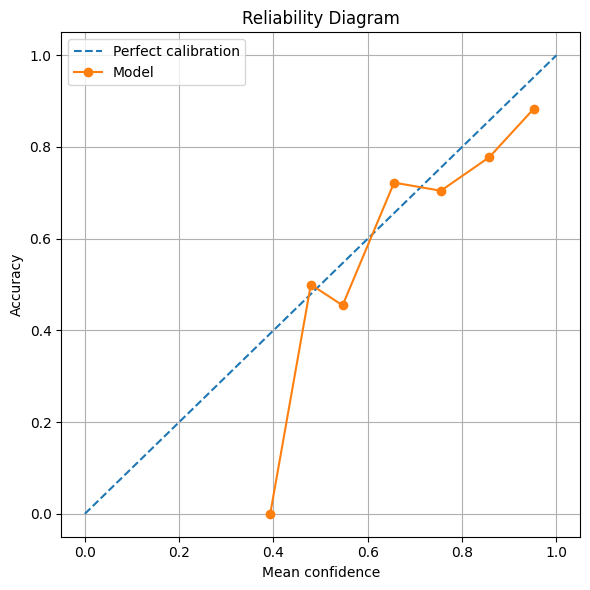

,mean_confidence,accuracy,count
0,0.393097,0.000000,1
1,0.479217,0.500000,8
2,0.546529,0.454545,22
3,0.655768,0.722222,36
4,0.754992,0.704545,44
5,0.857739,0.777778,54
6,0.952343,0.883721,129


Saved reliability diagram to: /kaggle/working/exp02_single_image_densenet121_loss_multiseed_confidence/figures/selected_loss_reliability_diagram.png


In [28]:
# ============================================================
# Reliability diagram for calibration analysis
# ============================================================

def plot_reliability_diagram(conf_df, n_bins=10, save_path=None):
    if len(conf_df) == 0:
        print("No confidence dataframe available. Reliability diagram skipped.")
        return pd.DataFrame()

    confidences = conf_df["confidence"].values
    correct = conf_df["correct"].values.astype(float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    bin_confidences = []
    bin_accuracies = []
    bin_counts = []

    for i in range(n_bins):
        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences >= lower) & (confidences < upper)

        if np.sum(in_bin) > 0:
            bin_confidences.append(float(np.mean(confidences[in_bin])))
            bin_accuracies.append(float(np.mean(correct[in_bin])))
            bin_counts.append(int(np.sum(in_bin)))

    reliability_df = pd.DataFrame({
        "mean_confidence": bin_confidences,
        "accuracy": bin_accuracies,
        "count": bin_counts,
    })

    reliability_df.to_csv(RESULTS_DIR / "selected_loss_reliability_bins.csv", index=False)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.plot(bin_confidences, bin_accuracies, marker="o", label="Model")
    plt.xlabel("Mean confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    display(reliability_df)
    return reliability_df


reliability_path = FIGURES_DIR / "selected_loss_reliability_diagram.png"

reliability_df = plot_reliability_diagram(
    confidence_df,
    n_bins=CONFIG.get("CONFIDENCE_BINS", 10),
    save_path=reliability_path,
)

print("Saved reliability diagram to:", reliability_path)


## 13.1 Per-class Recall and F1

In [29]:
per_class_reports = {}
for row in test_results:
    loss_name = row["loss_name"]
    y_true = test_predictions[loss_name]["y_true"]
    y_pred = test_predictions[loss_name]["y_pred"]
    print("=" * 80)
    print("Classification report:", loss_name)
    report_text = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
    print(report_text)
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    per_class_reports[loss_name] = report_dict
    per_class_df = pd.DataFrame(report_dict).T
    display(per_class_df)
    per_class_df.to_csv(RESULTS_DIR / f"{loss_name}_classification_report.csv")


Classification report: OrdinalCrossEntropyLoss
              precision    recall  f1-score   support

     0Normal     0.8462    0.8462    0.8462        91
   1Doubtful     0.7273    0.8182    0.7701        88
       2Mild     0.7308    0.5000    0.5938        38
   3Moderate     0.7949    0.8857    0.8378        35
     4Severe     0.8462    0.7857    0.8148        42

    accuracy                         0.7891       294
   macro avg     0.7890    0.7672    0.7725       294
weighted avg     0.7896    0.7891    0.7853       294



,precision,recall,f1-score,support
0Normal,0.846154,0.846154,0.846154,91.000000
1Doubtful,0.727273,0.818182,0.770053,88.000000
2Mild,0.730769,0.500000,0.593750,38.000000
3Moderate,0.794872,0.885714,0.837838,35.000000
4Severe,0.846154,0.785714,0.814815,42.000000
accuracy,0.789116,0.789116,0.789116,0.789116
macro avg,0.789044,0.767153,0.772522,294.000000
weighted avg,0.789552,0.789116,0.785285,294.000000


Classification report: ChenOrdinalLoss
              precision    recall  f1-score   support

     0Normal     0.8247    0.8791    0.8511        91
   1Doubtful     0.6970    0.7841    0.7380        88
       2Mild     0.6154    0.4211    0.5000        38
   3Moderate     0.9032    0.8000    0.8485        35
     4Severe     0.8293    0.8095    0.8193        42

    accuracy                         0.7721       294
   macro avg     0.7739    0.7388    0.7514       294
weighted avg     0.7694    0.7721    0.7670       294



,precision,recall,f1-score,support
0Normal,0.824742,0.879121,0.851064,91.000000
1Doubtful,0.696970,0.784091,0.737968,88.000000
2Mild,0.615385,0.421053,0.500000,38.000000
3Moderate,0.903226,0.800000,0.848485,35.000000
4Severe,0.829268,0.809524,0.819277,42.000000
accuracy,0.772109,0.772109,0.772109,0.772109
macro avg,0.773918,0.738758,0.751359,294.000000
weighted avg,0.769427,0.772109,0.766988,294.000000


Classification report: HybridChenOrdinalLoss
              precision    recall  f1-score   support

     0Normal     0.8125    0.8571    0.8342        91
   1Doubtful     0.7126    0.7045    0.7086        88
       2Mild     0.5676    0.5526    0.5600        38
   3Moderate     0.7838    0.8286    0.8056        35
     4Severe     0.8378    0.7381    0.7848        42

    accuracy                         0.7517       294
   macro avg     0.7429    0.7362    0.7386       294
weighted avg     0.7512    0.7517    0.7507       294



,precision,recall,f1-score,support
0Normal,0.812500,0.857143,0.834225,91.000000
1Doubtful,0.712644,0.704545,0.708571,88.000000
2Mild,0.567568,0.552632,0.560000,38.000000
3Moderate,0.783784,0.828571,0.805556,35.000000
4Severe,0.837838,0.738095,0.784810,42.000000
accuracy,0.751701,0.751701,0.751701,0.751701
macro avg,0.742867,0.736197,0.738632,294.000000
weighted avg,0.751154,0.751701,0.750698,294.000000


## 14. Confusion Matrix

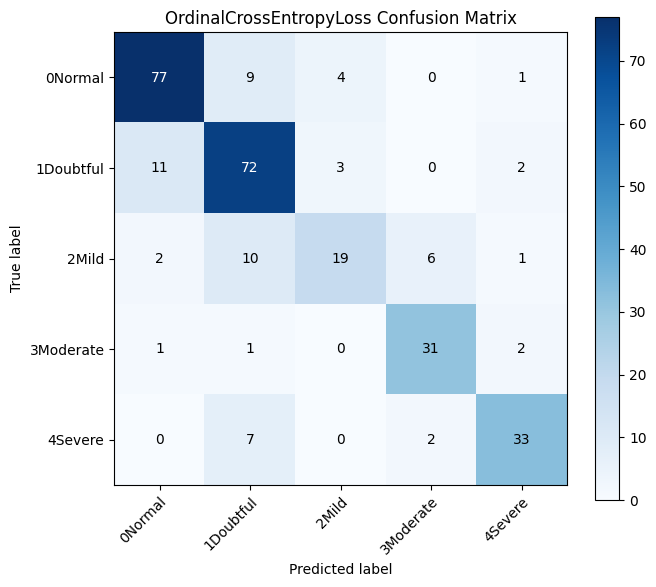

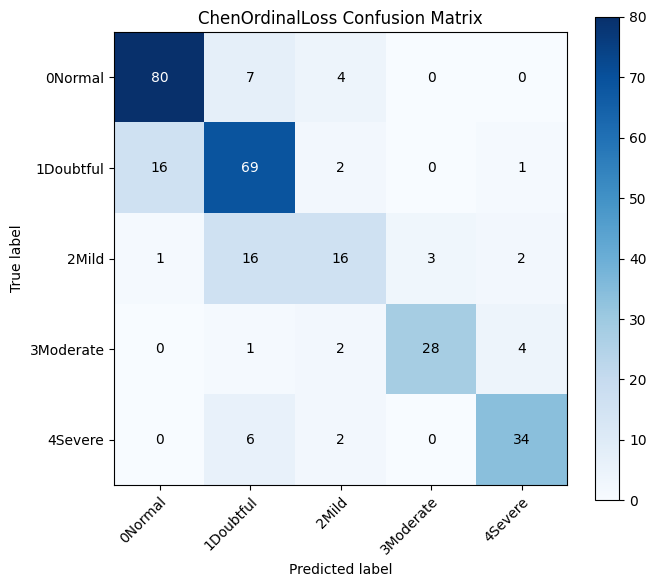

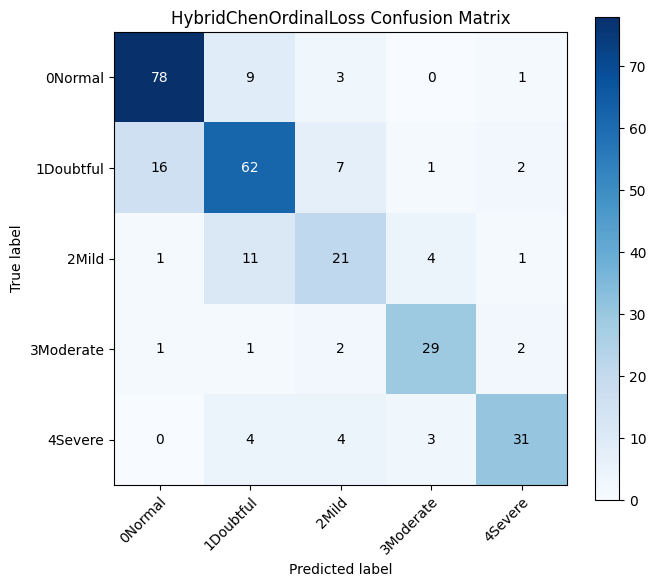

In [30]:
def plot_confusion_matrix(cm, labels, title, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(cm.shape[1]),
        yticks=np.arange(cm.shape[0]),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    threshold = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="white" if cm[i, j] > threshold else "black")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

for row in test_results:
    loss_name = row["loss_name"]
    y_true = test_predictions[loss_name]["y_true"]
    y_pred = test_predictions[loss_name]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    np.save(RESULTS_DIR / f"{loss_name}_confusion_matrix.npy", cm)
    plot_confusion_matrix(cm, class_names, f"{loss_name} Confusion Matrix", FIGURES_DIR / f"{loss_name}_confusion_matrix.png")


## 15. Error Analysis

Adjacent errors mean the predicted grade differs from the true grade by exactly 1. Distant errors mean the predicted grade differs by 2 or more.

,loss_name,correct,adjacent_errors,distant_errors,total_errors,mean_absolute_error
1,ChenOrdinalLoss,227,50,17,67,0.309524
0,OrdinalCrossEntropyLoss,232,43,19,62,0.316327
2,HybridChenOrdinalLoss,221,54,19,73,0.343537


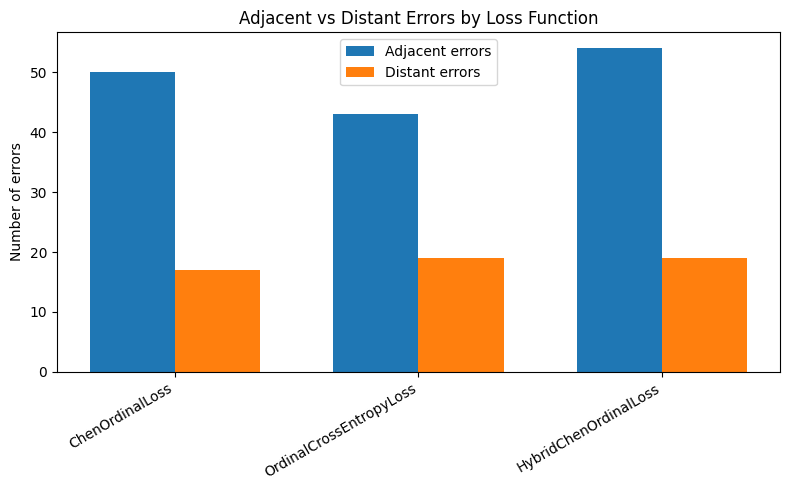

In [31]:
error_rows = []
for row in test_results:
    loss_name = row["loss_name"]
    y_true = test_predictions[loss_name]["y_true"]
    y_pred = test_predictions[loss_name]["y_pred"]
    diff = np.abs(y_true - y_pred)
    error_rows.append({
        "loss_name": loss_name,
        "correct": int(np.sum(diff == 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
        "total_errors": int(np.sum(diff > 0)),
        "mean_absolute_error": float(np.mean(diff)),
    })
error_df = pd.DataFrame(error_rows).sort_values("distant_errors")
display(error_df)
error_df.to_csv(RESULTS_DIR / "loss_comparison_error_analysis.csv", index=False)

plt.figure(figsize=(8, 5))
x = np.arange(len(error_df))
width = 0.35
plt.bar(x - width/2, error_df["adjacent_errors"], width, label="Adjacent errors")
plt.bar(x + width/2, error_df["distant_errors"], width, label="Distant errors")
plt.xticks(x, error_df["loss_name"], rotation=30, ha="right")
plt.ylabel("Number of errors")
plt.title("Adjacent vs Distant Errors by Loss Function")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "adjacent_vs_distant_errors.png", dpi=200, bbox_inches="tight")
plt.show()


## 16. Grad-CAM

Grad-CAM is shown for one correctly classified image and one misclassified image using the best-performing loss function based on test QWK.

Best loss for Grad-CAM: ChenOrdinalLoss


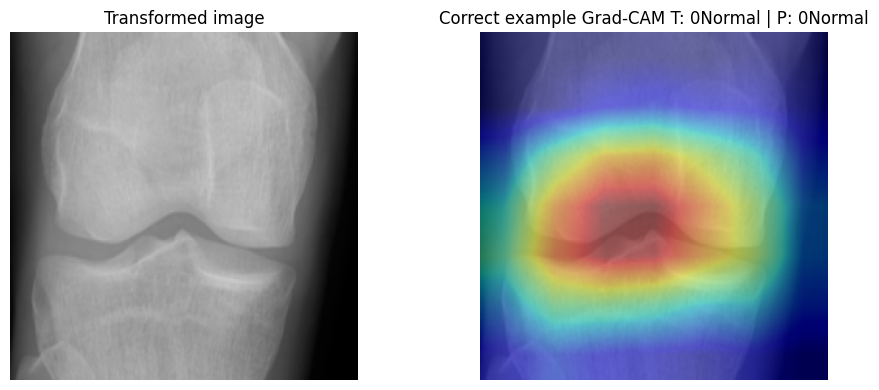

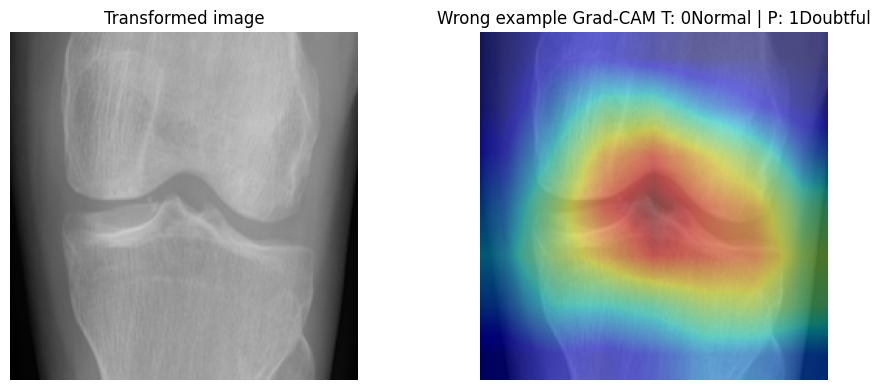

In [32]:
best_loss_name = test_results_df.iloc[0]["loss_name"]
best_model_path = [r for r in all_experiment_records if r["loss_name"] == best_loss_name][0]["model_path"]
best_model = load_best_model_for_loss(best_loss_name, best_model_path)
print("Best loss for Grad-CAM:", best_loss_name)

class DenseNetGradCAM:
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.activations = None
        self.gradients = None
        self.target_layer = self.model.features.denseblock4
        self.forward_handle = self.target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        if target_class is None:
            target_class = logits.argmax(dim=1).item()
        score = logits[:, target_class].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


def show_gradcam_for_index(model, dataset, idx, y_true, y_pred, title_prefix):
    img_tensor, label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    gradcam = DenseNetGradCAM(model)
    cam, logits = gradcam.generate(input_tensor, target_class=int(y_pred[idx]))
    gradcam.close()
    img_np = denormalize_tensor(img_tensor)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("Transformed image")
    plt.subplot(1, 2, 2)
    plt.imshow(img_np)
    plt.imshow(cam, cmap="jet", alpha=0.45)
    plt.axis("off")
    plt.title(f"{title_prefix} T: {class_names[int(y_true[idx])]} | P: {class_names[int(y_pred[idx])]}")
    plt.tight_layout()
    plt.show()

best_true = test_predictions[best_loss_name]["y_true"]
best_pred = test_predictions[best_loss_name]["y_pred"]
correct_indices = np.where(best_true == best_pred)[0]
wrong_indices = np.where(best_true != best_pred)[0]

if len(correct_indices) > 0:
    show_gradcam_for_index(best_model, test_dataset, int(correct_indices[0]), best_true, best_pred, "Correct example Grad-CAM")
if len(wrong_indices) > 0:
    show_gradcam_for_index(best_model, test_dataset, int(wrong_indices[0]), best_true, best_pred, "Wrong example Grad-CAM")


## 17. Final Summary

# Experiment Conclusion

This experiment compares three ordinal-aware loss functions using the same single-image DenseNet121 model. The purpose is to test whether changing the loss function alone improves ordinal grading performance before introducing 4-crop input or class imbalance handling.

In [33]:
print("Final test summary sorted by QWK:")
display(test_results_df)
print("Error analysis summary:")
display(error_df)

best_row = test_results_df.iloc[0].to_dict()
selected_loss_name = str(best_row["loss_name"])
print("Best loss function:", selected_loss_name)
print("Best test QWK:", best_row["qwk"])
print("Best test accuracy:", best_row["accuracy"])
print("Best test MAE:", best_row["mae"])
print("Best test distant errors:", best_row["distant_errors"])

if "multi_seed_summary_df" in globals() and len(multi_seed_summary_df) > 0:
    print("\nMulti-seed robustness summary:")
    display(multi_seed_summary_df)

if "confidence_summary" in globals() and len(confidence_summary) > 0:
    print("\nConfidence summary:")
    for k, v in confidence_summary.items():
        print(f"{k}: {v}")

summary_text = "\n".join([
    "Experiment Conclusion",
    "---------------------",
    "Model: Single-image DenseNet121",
    "Compared losses: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLoss",
    f"Best loss: {selected_loss_name}",
    f"Best test accuracy: {best_row['accuracy']:.4f}",
    f"Best test macro F1: {best_row['macro_f1']:.4f}",
    f"Best test weighted F1: {best_row['weighted_f1']:.4f}",
    f"Best test QWK: {best_row['qwk']:.4f}",
    f"Best test MAE: {best_row['mae']:.4f}",
    f"Best test adjacent errors: {best_row['adjacent_errors']}",
    f"Best test distant errors: {best_row['distant_errors']}",
    "",
    "Interpretation:",
    "Ordinal-aware losses are evaluated because knee OA grading has an ordered severity structure.",
    "The best loss should not only improve accuracy, but also reduce distant grading errors.",
    "Multi-seed robustness checks whether the selected loss remains stable under different initializations and train-shuffle orders.",
    "Confidence outputs identify calibration behavior and high-confidence mistakes for the selected loss.",
])
print(summary_text)


Final test summary sorted by QWK:


,loss_name,save_tag,seed,best_epoch,best_val_qwk,accuracy,macro_f1,weighted_f1,qwk,mae,total_errors,adjacent_errors,distant_errors,loss
1,ChenOrdinalLoss,ChenOrdinalLoss,42,5,0.915619,0.772109,0.751359,0.766988,0.867199,0.309524,67,50,17,3.146048
2,HybridChenOrdinalLoss,HybridChenOrdinalLoss,42,14,0.888504,0.751701,0.738632,0.750698,0.844523,0.343537,73,54,19,0.824890
0,OrdinalCrossEntropyLoss,OrdinalCrossEntropyLoss,42,11,0.919082,0.789116,0.772522,0.785285,0.841858,0.316327,62,43,19,0.769250


Error analysis summary:


,loss_name,correct,adjacent_errors,distant_errors,total_errors,mean_absolute_error
1,ChenOrdinalLoss,227,50,17,67,0.309524
0,OrdinalCrossEntropyLoss,232,43,19,62,0.316327
2,HybridChenOrdinalLoss,221,54,19,73,0.343537


Best loss function: ChenOrdinalLoss
Best test QWK: 0.8671992631038209
Best test accuracy: 0.7721088435374149
Best test MAE: 0.30952380952380953
Best test distant errors: 17

Multi-seed robustness summary:


,metric,mean,std,min,max,mean±std
0,test_accuracy,0.767347,0.008220,0.751701,0.775510,0.7673 ± 0.0082
1,test_macro_f1,0.750060,0.011156,0.729902,0.761538,0.7501 ± 0.0112
2,test_weighted_f1,0.763437,0.008624,0.746790,0.771759,0.7634 ± 0.0086
3,test_qwk,0.871146,0.007515,0.861651,0.882260,0.8711 ± 0.0075
4,test_mae,0.305442,0.004999,0.295918,0.309524,0.3054 ± 0.0050
5,test_total_errors,68.400000,2.416609,66.000000,73.000000,68.4000 ± 2.4166
6,test_adjacent_errors,53.800000,4.308132,50.000000,62.000000,53.8000 ± 4.3081
7,test_distant_errors,14.600000,2.059126,11.000000,17.000000,14.6000 ± 2.0591



Confidence summary:
mean_confidence: 0.8239725281794866
median_confidence: 0.874908983707428
mean_confidence_correct: 0.8477722571809911
mean_confidence_wrong: 0.7433376254430458
mean_margin_top1_top2: 0.6912022366815683
mean_entropy: 0.31215356498145735
high_confidence_wrong_count_0.80: 27
high_confidence_wrong_count_0.90: 15
ece_10_bins: 0.06926930852893257
Experiment Conclusion
---------------------
Model: Single-image DenseNet121
Compared losses: OrdinalCrossEntropyLoss, ChenOrdinalLoss, HybridChenOrdinalLoss
Best loss: ChenOrdinalLoss
Best test accuracy: 0.7721
Best test macro F1: 0.7514
Best test weighted F1: 0.7670
Best test QWK: 0.8672
Best test MAE: 0.3095
Best test adjacent errors: 50
Best test distant errors: 17

Interpretation:
Ordinal-aware losses are evaluated because knee OA grading has an ordered severity structure.
The best loss should not only improve accuracy, but also reduce distant grading errors.
Multi-seed robustness checks whether the selected loss remains stab

## 18. Save Results

def make_json_serializable(obj):
    """Convert NumPy/Pandas objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    try:
        if pd.isna(obj):
            return None
    except (TypeError, ValueError):
        pass
    return obj


metrics_json = {
    "config": CONFIG,
    "loss_matrices": loss_matrix_records,
    "validation_summary": val_summary_df.to_dict(orient="records"),
    "test_results": test_results_df.to_dict(orient="records"),
    "error_analysis": error_df.to_dict(orient="records"),
    "best_loss_name": selected_loss_name,
    "best_metrics": best_row,
}

if "seed_results_df" in globals() and len(seed_results_df) > 0:
    metrics_json["multi_seed_results"] = seed_results_df.to_dict(orient="records")

if "multi_seed_summary_df" in globals() and len(multi_seed_summary_df) > 0:
    metrics_json["multi_seed_summary"] = multi_seed_summary_df.to_dict(orient="records")

if "confidence_summary" in globals() and len(confidence_summary) > 0:
    metrics_json["confidence_summary"] = confidence_summary
    metrics_json["confidence_metrics"] = confidence_metrics

if "confidence_by_class_df" in globals() and len(confidence_by_class_df) > 0:
    metrics_json["confidence_by_class"] = confidence_by_class_df.to_dict(orient="records")

summary_json = {
    "experiment_name": CONFIG["EXPERIMENT_NAME"],
    "model": CONFIG["MODEL_NAME"],
    "best_loss_name": selected_loss_name,
    "best_test_accuracy": best_row["accuracy"],
    "best_test_macro_f1": best_row["macro_f1"],
    "best_test_weighted_f1": best_row["weighted_f1"],
    "best_test_qwk": best_row["qwk"],
    "best_test_mae": best_row["mae"],
    "best_test_total_errors": best_row["total_errors"],
    "best_test_adjacent_errors": best_row["adjacent_errors"],
    "best_test_distant_errors": best_row["distant_errors"],
}

if "multi_seed_summary_df" in globals() and len(multi_seed_summary_df) > 0:
    summary_json["multi_seed_summary"] = multi_seed_summary_df.to_dict(orient="records")

if "confidence_summary" in globals() and len(confidence_summary) > 0:
    summary_json["mean_confidence"] = confidence_summary.get("mean_confidence")
    summary_json["mean_confidence_correct"] = confidence_summary.get("mean_confidence_correct")
    summary_json["mean_confidence_wrong"] = confidence_summary.get("mean_confidence_wrong")
    summary_json["mean_margin_top1_top2"] = confidence_summary.get("mean_margin_top1_top2")
    summary_json["mean_entropy"] = confidence_summary.get("mean_entropy")
    summary_json["ece_10_bins"] = confidence_summary.get("ece_10_bins")
    summary_json["high_confidence_wrong_count_0.80"] = confidence_summary.get("high_confidence_wrong_count_0.80")
    summary_json["high_confidence_wrong_count_0.90"] = confidence_summary.get("high_confidence_wrong_count_0.90")

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(make_json_serializable(metrics_json), f, indent=4)
with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(make_json_serializable(summary_json), f, indent=4)
with open(RESULTS_DIR / "experiment_summary.txt", "w") as f:
    f.write(summary_text)
val_summary_df.to_csv(RESULTS_DIR / "validation_summary.csv", index=False)
test_results_df.to_csv(RESULTS_DIR / "test_summary.csv", index=False)
error_df.to_csv(RESULTS_DIR / "error_summary.csv", index=False)

best_y_true = test_predictions[best_loss_name]["y_true"]
best_y_pred = test_predictions[best_loss_name]["y_pred"]
best_cm = confusion_matrix(best_y_true, best_y_pred)
np.save(RESULTS_DIR / "confusion_matrix.npy", best_cm)
plot_confusion_matrix(
    best_cm,
    labels=class_names,
    title=f"Best Loss Confusion Matrix: {best_loss_name}",
    save_path=FIGURES_DIR / "confusion_matrix.png"
)

print("Saved metrics to:", RESULTS_DIR / "metrics.json")
print("Saved summary to:", RESULTS_DIR / "summary.json")
print("Saved confusion matrix figure to:", FIGURES_DIR / "confusion_matrix.png")
print("Saved all outputs under:", SAVE_DIR)
